# Import setup variables

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
from pathlib import Path
import glob



# Read in genetic PCs

In [2]:
import json
ancestry_file = "/home/jupyter/workspace/vwb-aou-datasets-controlled/v9/wgs/short_read/snpindel/aux/ancestry/ancestry_preds.tsv"
ancestry = pd.read_csv(ancestry_file, sep="\t", converters={"pca_features": json.loads})

In [3]:
# Make PC columns 
pc = pd.DataFrame([pd.Series(x) for x in ancestry.pca_features])
pc.columns = ['PC_{}'.format(x+1) for x in pc.columns]

# Add PC columns back to dataframe 
ancestry = pd.concat([ancestry, pc], axis=1)
ancestry.rename(columns={ancestry.columns[0]: "person_id"}, inplace=True)

# Split out training data 

Those without EHR data will be used to train the PRS

In [4]:
dataset_id='C2024Q3R9'
dataset=!wb resolve --id {dataset_id} 
dataset_str = dataset[0]
os.environ['WORKSPACE_CDR'] = dataset_str
CDR_version = os.getenv("WORKSPACE_CDR")

# first query from condition occurrence to get number of distinct codes and ehr length
query="""SELECT person_id, min(condition_start_date) as min_cond_date,max(condition_start_date)as max_cond_date,
COUNT(DISTINCT condition_concept_id) as cond_code_cnt, COUNT(DISTINCT visit_occurrence_id) as num_cond_visits
FROM `"""+CDR_version+""".condition_occurrence` WHERE condition_start_date >='1880-01-01'
GROUP BY person_id """

ehr_covariate=pd.read_gbq(query, dialect="standard")
# EHR Length is a bit subtle here. Observation date is a little tricky because birthdate is used in observation. 
# What we need to do is take the relevant codes from observation and find the minimum and maximum dates overall
query = ("""
    SELECT distinct person_id, min(observation_date) as min_obs_date, max(observation_date) as max_obs_date, 
    COUNT(DISTINCT observation_concept_id) as observation_code_cnt, COUNT(DISTINCT visit_occurrence_id) as num_obs_visits
    FROM 
        (SELECT DISTINCT person_id, observation_source_concept_id, observation_source_value, 
        observation_date, observation_concept_id, visit_occurrence_id
            FROM `"""+ str(CDR_version) +""".observation`) AS obs
            INNER JOIN 
            (SELECT DISTINCT concept_id, concept_name, concept_code, vocabulary_id 
                    FROM `"""+str(CDR_version)+""".concept`
                    where (vocabulary_id ='ICD9CM') or 
                (vocabulary_id ='ICD10CM')) as concept 
                on concept.concept_id = obs.observation_source_concept_id
    group by person_id
    """)
observation_code_dates = pd.read_gbq(query, dialect="standard")
    # note, this procedure takes into consideration NaTs, so if a person didn't have an observation code, it will
    # automatically take the minimum condition occurrence date.
ehr_covariate_plus = pd.merge(observation_code_dates, ehr_covariate, on="person_id", how = 'outer')

/tmp/ipykernel_32370/1367970558.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  ehr_covariate=pd.read_gbq(query, dialect="standard")
/tmp/ipykernel_32370/1367970558.py:31: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  observation_code_dates = pd.read_gbq(query, dialect="standard")


# Make training and testing cohorts

In [5]:
test_pcs_df = ancestry[ancestry['person_id'].isin(ehr_covariate_plus['person_id'])]
train_pcs_df = ancestry[~ancestry['person_id'].isin(ehr_covariate_plus['person_id'])]

## Load in calculated PGS

In [6]:
env_path = "/home/jupyter/workspace/workspace-bucket/calculate_pgs/plink_results/latest_run.env"

with open(env_path) as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith("#"):
            key, value = line.split("=", 1)
            os.environ[key] = value.strip('"').strip("'")

PGS = os.environ["PGS"]
RUN_ID = os.environ["RUN_ID"]
OUTPUT_PATH = os.environ["OUTPUT_PATH"]

PGS_df = pd.read_csv(f"{OUTPUT_PATH}/{PGS}_combined_chr1_22_{RUN_ID}.csv")
PGS_df.rename(columns={PGS_df.columns[0]: "person_id"}, inplace=True)

In [7]:
# Make sure training and testing IDs have PGS
print(len(test_pcs_df))
test_pcs_df_safe = test_pcs_df[test_pcs_df['person_id'].isin(PGS_df['person_id'])]
print(len(test_pcs_df_safe))

print(len(train_pcs_df))
train_pcs_df_safe = train_pcs_df[train_pcs_df['person_id'].isin(PGS_df['person_id'])]
print(len(train_pcs_df_safe))

313104
286164
222558
123816


## Downsample training cohort

In [8]:
# --- 5. Print ancestry distribution before sampling ---
print("Before sampling:")
ancestry_counts = train_pcs_df_safe["ancestry_pred"].value_counts()
print(ancestry_counts)

# --- 6. Stratified downsampling to second smallest group ---
np.random.seed(246)

second_smallest_n = ancestry_counts.sort_values().iloc[1]

print(f"Downsampling each ancestry group to n={second_smallest_n}")

train_pcs_df_safe = (
    train_pcs_df_safe.groupby("ancestry_pred", group_keys=False)
    .apply(lambda x: x.sample(n=min(second_smallest_n, len(x)), replace=False))
)

# --- 7. Check result ---
print("After sampling:")
print(train_pcs_df_safe['ancestry_pred'].value_counts())

Before sampling:
ancestry_pred
eur    62936
amr    27330
afr    26611
eas     4724
sas     1743
mid      472
Name: count, dtype: int64
Downsampling each ancestry group to n=1743
After sampling:
ancestry_pred
afr    1743
amr    1743
eas    1743
eur    1743
sas    1743
mid     472
Name: count, dtype: int64


/tmp/ipykernel_32370/4091460298.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(second_smallest_n, len(x)), replace=False))


# Functions to adjust PRS for genetic PCs

In [9]:
# function to extract pcs (+ 1 vec) and scores as numpy arrays
def extract_pcs_and_scores(df, pc_indices):
    pcs_np = df[[f'PC_{i}' for i in pc_indices]].to_numpy()
    n_rows = pcs_np.shape[0]
    pcs_np = np.append(np.repeat(1, n_rows).reshape(n_rows, 1), pcs_np, axis = 1)
    scores = df['SCORE'].to_numpy()
    return pcs_np, scores

def extract_standardized_pcs_and_scores(df, pc_indices):
    pcs_np = df[[f'PC_{i}' for i in pc_indices]].to_numpy()
    pcs_np = (pcs_np - np.mean(pcs_np, axis = 0))/np.std(pcs_np, axis = 0)
    n_rows = pcs_np.shape[0]
    pcs_np = np.append(np.repeat(1, n_rows).reshape(n_rows, 1), pcs_np, axis = 1)
    scores = df['SCORE'].to_numpy()
    return pcs_np, scores

# function to predict mean
def f_mu(pcs, theta):
    return np.dot(pcs, theta)

# function to predict variance
def f_var(pcs, theta):
    return np.exp(np.dot(pcs, theta))

# objective function
# returns loss, gradient
def obj(pcs, scores, theta):
    split_index = pcs.shape[1]
    
    theta_mu = theta[:split_index]
    theta_var = theta[split_index:]
    mu = f_mu(pcs, theta_mu)
    var = f_var(pcs, theta_var)
    # loss is - log of normal distribution (with constant log sqrt(2pi) removed)
    loss = np.sum(np.log(np.sqrt(var)) + (1/2)*(scores-mu)**2/var)
    
    #gradient of loss
    mu_coeff = -(scores-mu)/var
    sig_coeff = 1/2 - (1/2)*(scores-mu)**2/var
    grad = np.append(np.sum(pcs * mu_coeff[:,np.newaxis], axis=0), np.sum(pcs * sig_coeff[:, np.newaxis], axis=0))
    
    return loss, grad

def obj_L1(pcs, scores, theta, l):
    unreg_loss, unreg_grad = obj(pcs, scores, theta)
    loss = unreg_loss + l*np.sum(np.abs(theta))
    grad = unreg_grad + l*np.sign(theta)
    return loss, grad

def adjust_scores(pcs, scores, theta):
    split_index = pcs.shape[1]
    
    theta_mu = theta[:split_index]
    theta_var = theta[split_index:]
    mu = f_mu(pcs, theta_mu)
    var = f_var(pcs, theta_var)
    
    adjusted_scores = (scores - mu)/np.sqrt(var)
    return adjusted_scores

In [10]:
from scipy.optimize import minimize

PGS_df_indexed = PGS_df.set_index("person_id")
train_pcs_indexed = train_pcs_df_safe.set_index("person_id")
test_pcs_indexed = test_pcs_df_safe.set_index("person_id")

train_scores_and_pcs = PGS_df_indexed.join(train_pcs_indexed, how="inner")
test_scores_and_pcs = PGS_df_indexed.join(test_pcs_indexed, how="inner")
    
n_pcs = 16
train_pcs, train_scores = extract_pcs_and_scores(train_scores_and_pcs, range(1, n_pcs + 1))
x0 = np.append(np.append(train_scores.mean(), np.repeat(0, n_pcs)), 
                np.append(np.log(train_scores.var()), np.repeat(0, n_pcs))
                )
res = minimize(lambda theta : obj(train_pcs, train_scores, theta), x0, method="BFGS", jac=True)
test_pcs, test_scores = extract_pcs_and_scores(test_scores_and_pcs, range(1, n_pcs + 1))
    
adjusted_train_scores = adjust_scores(train_pcs, train_scores, res.x)
adjusted_test_scores = adjust_scores(test_pcs, test_scores, res.x)
    
df_train_adjusted = train_scores_and_pcs.copy()[["ancestry_pred", "SCORE"]]
df_train_adjusted["adjusted_score"] = adjusted_train_scores
    
df_test_adjusted = test_scores_and_pcs.copy()[["ancestry_pred", "SCORE"]]
df_test_adjusted["adjusted_score"] = adjusted_test_scores
    

    
 

In [11]:
print(len(df_test_adjusted))

286164


In [12]:
# Save score file
OUTPUT_PATH = Path(OUTPUT_PATH)

filename = f"{PGS}_final_adjusted_{RUN_ID}.csv"
df_test_adjusted.to_csv(
    OUTPUT_PATH / filename,
    sep=","
)

# Plot PRS distributions by ancestry groups pre and post adjustment

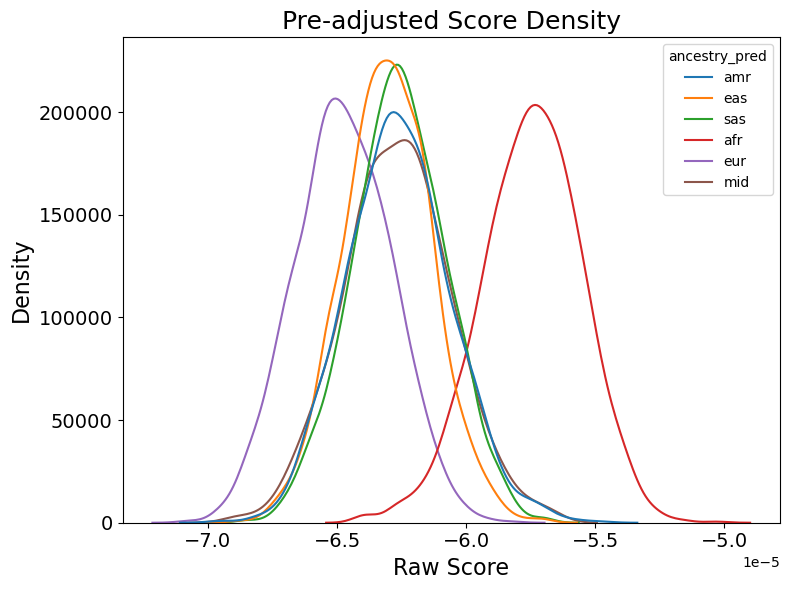

Saved plot to: /home/jupyter/workspace/workspace-bucket/calculate_pgs/plink_results/PGS002308_GRCh38_20260909_135450


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.kdeplot(
    data=df_train_adjusted,
    x="SCORE",
    hue="ancestry_pred",
    common_norm=False
)

plt.xlabel("Raw Score", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.title("Pre-adjusted Score Density", fontsize=18)

plt.tick_params(axis="both", which="major", labelsize=14)
plt.tick_params(axis="both", which="minor", labelsize=12)

plt.tight_layout()

filename = "pre_adjusted_score_density.png"
OUTPUT_PATH = Path(OUTPUT_PATH)
plt.savefig(OUTPUT_PATH / filename, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved plot to: {OUTPUT_PATH}")

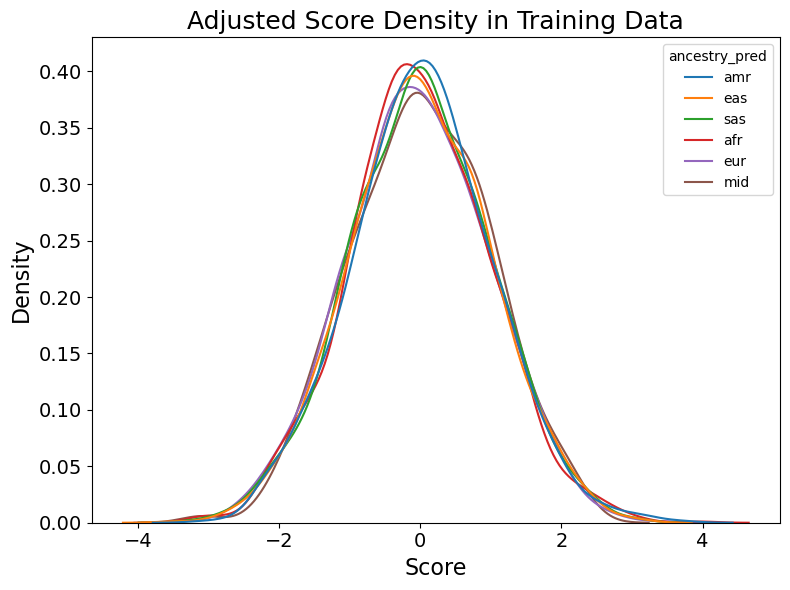

Saved plot to: /home/jupyter/workspace/workspace-bucket/calculate_pgs/plink_results/PGS002308_GRCh38_20260909_135450


In [14]:
plt.figure(figsize=(8, 6))

sns.kdeplot(
    data=df_train_adjusted,
    x="adjusted_score",
    hue="ancestry_pred",
    common_norm=False
)

plt.xlabel("Score", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.title("Adjusted Score Density in Training Data", fontsize=18)

plt.tick_params(axis="both", which="major", labelsize=14)
plt.tick_params(axis="both", which="minor", labelsize=12)

plt.tight_layout()

filename = "post_adjusted_score_training_data_density.png"
OUTPUT_PATH = Path(OUTPUT_PATH)
plt.savefig(OUTPUT_PATH / filename, dpi=300, bbox_inches="tight")


plt.show()
plt.close()

print(f"Saved plot to: {OUTPUT_PATH}")

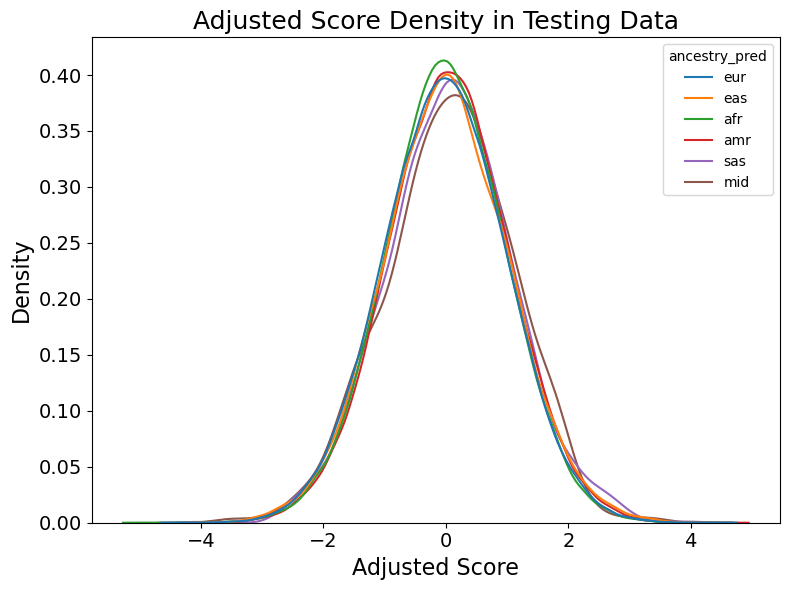

Saved plot to: /home/jupyter/workspace/workspace-bucket/calculate_pgs/plink_results/PGS002308_GRCh38_20260909_135450


In [15]:
plt.figure(figsize=(8, 6))

sns.kdeplot(
    data=df_test_adjusted,
    x="adjusted_score",
    hue="ancestry_pred",
    common_norm=False
)

plt.xlabel("Adjusted Score", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.title("Adjusted Score Density in Testing Data", fontsize=18)

plt.tick_params(axis="both", which="major", labelsize=14)
plt.tick_params(axis="both", which="minor", labelsize=12)

plt.tight_layout()

filename = "post_adjusted_score_testing_data_density.png"
OUTPUT_PATH = Path(OUTPUT_PATH)
plt.savefig(OUTPUT_PATH / filename, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved plot to: {OUTPUT_PATH}")